<a href="https://colab.research.google.com/github/GustavoMMayer/mini-projeto-visao-computacional/blob/sprint-1-configuracao/Mini_Projeto_Visao_Computacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from google.colab import drive
drive.mount('/content/drive')

import os

caminho_drive = "/content/drive/MyDrive"

for item in os.listdir(caminho_drive):
    print(item)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab Notebooks
Inventário de Valores.gdoc
Mini-Projeto Avaliativo - Módulo 2 - Semana 07


In [15]:
caminho_dataset = "/content/drive/MyDrive/Mini-Projeto Avaliativo - Módulo 2 - Semana 07/casting_512x512"

print(os.listdir(caminho_dataset))
# Caminhos das duas classes
pasta_def = os.path.join(caminho_dataset, "def_front")
pasta_ok = os.path.join(caminho_dataset, "ok_front")

# Lista somente arquivos de imagem
imagens_def = [
    arquivo for arquivo in os.listdir(pasta_def)
    if arquivo.lower().endswith((".jpg", ".jpeg", ".png"))
]

imagens_ok = [
    arquivo for arquivo in os.listdir(pasta_ok)
    if arquivo.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Quantidade de imagens
print("Imagens defeituosas:", len(imagens_def))
print("Imagens OK:", len(imagens_ok))
print("Total de imagens:", len(imagens_def) + len(imagens_ok))

['def_front', 'ok_front']
Imagens defeituosas: 781
Imagens OK: 519
Total de imagens: 1300


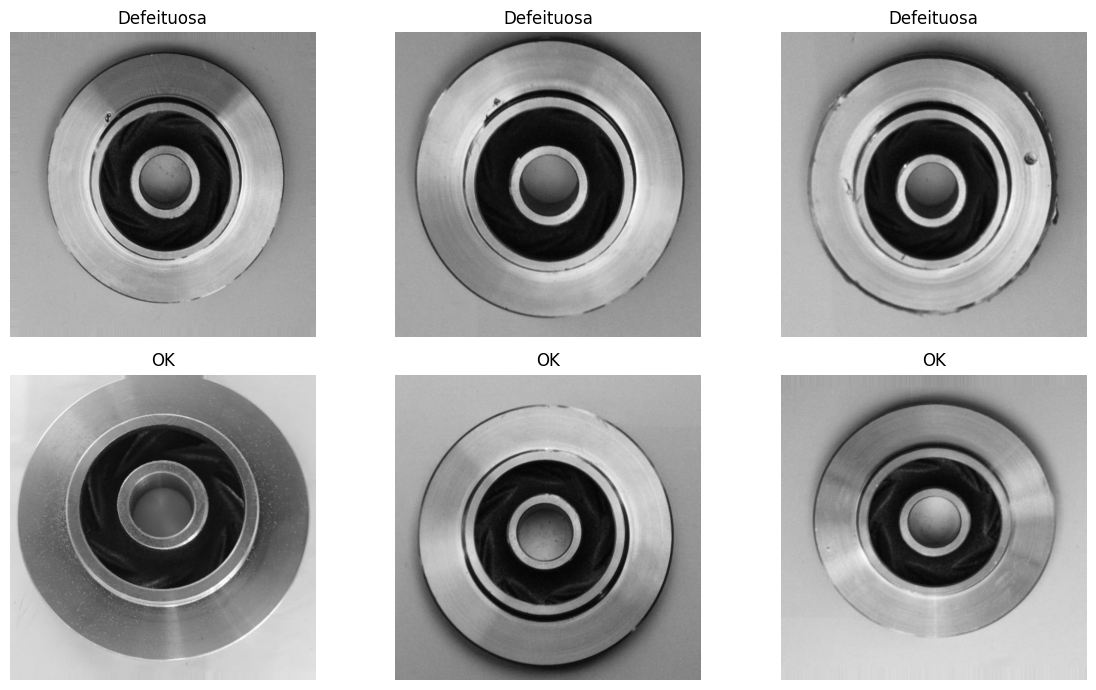

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

# Cria uma figura com 6 espaços
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

# Mostra 3 imagens defeituosas
for i in range(3):
    caminho = os.path.join(pasta_def, imagens_def[i])
    imagem = Image.open(caminho)

    axes[0, i].imshow(imagem, cmap="gray")
    axes[0, i].set_title("Defeituosa")
    axes[0, i].axis("off")

# Mostra 3 imagens OK
for i in range(3):
    caminho = os.path.join(pasta_ok, imagens_ok[i])
    imagem = Image.open(caminho)

    axes[1, i].imshow(imagem, cmap="gray")
    axes[1, i].set_title("OK")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

# 4. Análise Exploratória com OpenCV

Nesta etapa será realizada uma análise visual das imagens utilizando técnicas
clássicas de processamento de imagens.

O objetivo é compreender as características visuais dos possíveis defeitos
presentes nas peças antes da aplicação de uma Rede Neural Convolucional.

Serão utilizadas as seguintes técnicas:

- Conversão para escala de cinza (Grayscale)
- Suavização de ruídos (Gaussian Blur)
- Limiarização (Thresholding)
- Detecção de bordas (Canny)
- Operações morfológicas

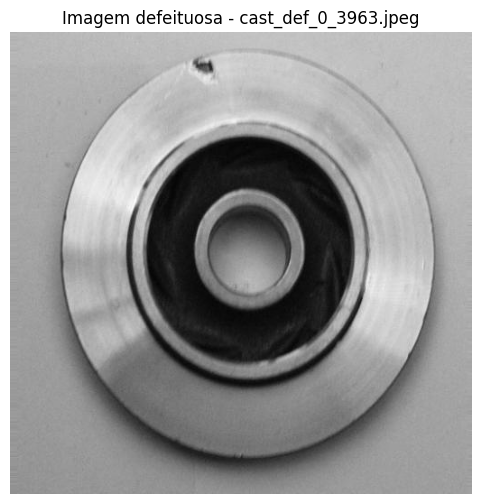

In [17]:
import random
import cv2
import matplotlib.pyplot as plt

# Escolhe aleatoriamente uma imagem defeituosa
nome_imagem = random.choice(imagens_def)

caminho_imagem = os.path.join(pasta_def, nome_imagem)

# Carrega a imagem usando OpenCV
imagem = cv2.imread(caminho_imagem)

# OpenCV carrega imagens coloridas em BGR.
# Para exibir corretamente com Matplotlib, convertemos para RGB.
imagem_rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(imagem_rgb)
plt.title(f"Imagem defeituosa - {nome_imagem}")
plt.axis("off")
plt.show()

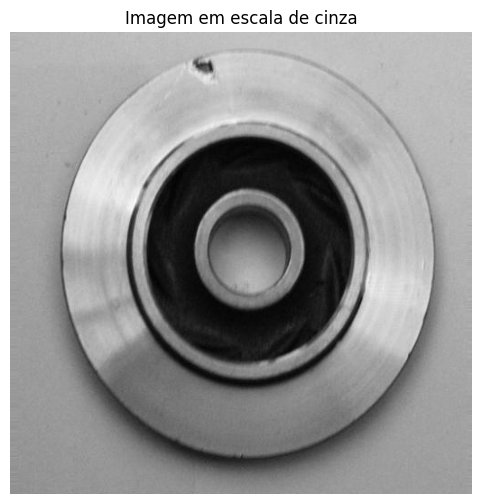

In [18]:
# Conversão para escala de cinza
cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(cinza, cmap="gray")
plt.title("Imagem em escala de cinza")
plt.axis("off")
plt.show()

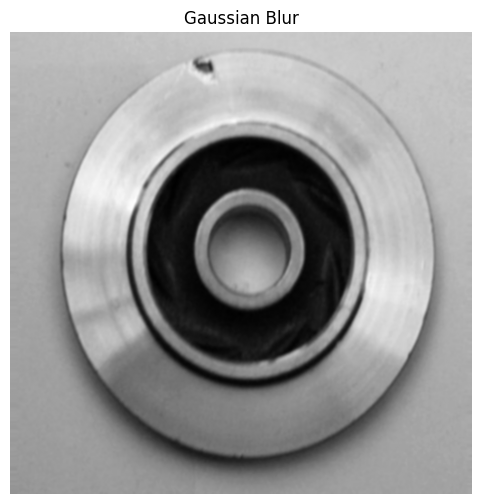

In [19]:
blur = cv2.GaussianBlur(cinza, (5, 5), 0)

plt.figure(figsize=(6, 6))
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")
plt.show()

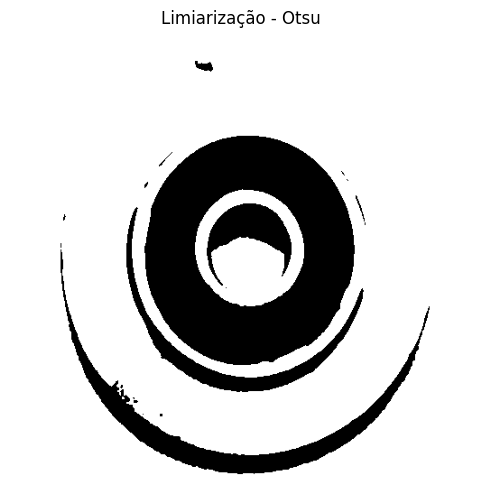

In [20]:
# Limiarização automática utilizando o método de Otsu
_, threshold = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(6, 6))
plt.imshow(threshold, cmap="gray")
plt.title("Limiarização - Otsu")
plt.axis("off")
plt.show()

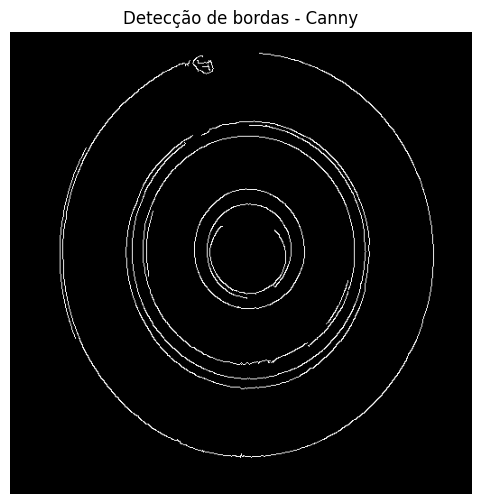

In [21]:
# Detecção de bordas utilizando Canny
bordas = cv2.Canny(blur, 50, 150)

plt.figure(figsize=(6, 6))
plt.imshow(bordas, cmap="gray")
plt.title("Detecção de bordas - Canny")
plt.axis("off")
plt.show()

# 5. Operações Morfológicas

Após a detecção de bordas, serão aplicadas operações morfológicas para
tratar as regiões encontradas e reduzir pequenas imperfeições na imagem.

Serão utilizadas as operações de erosão e dilatação.

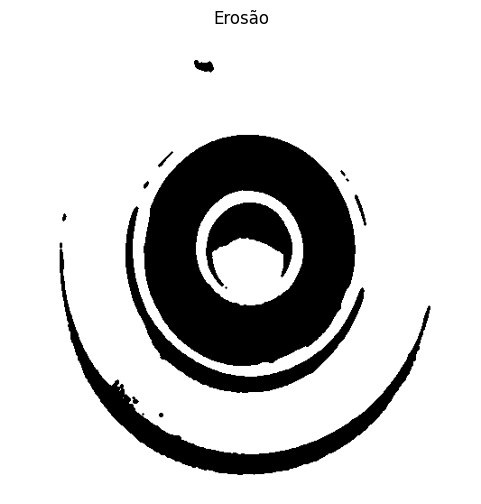

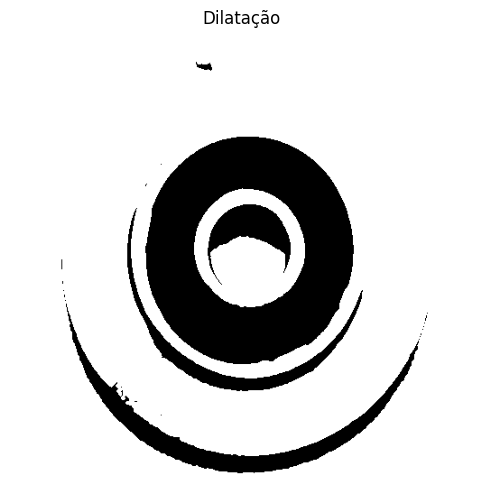

In [22]:
# Criação do elemento estruturante
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (3, 3)
)

# Erosão
erosao = cv2.erode(threshold, kernel, iterations=1)

plt.figure(figsize=(6, 6))
plt.imshow(erosao, cmap="gray")
plt.title("Erosão")
plt.axis("off")
plt.show()

# Dilatação
dilatacao = cv2.dilate(threshold, kernel, iterations=1)

plt.figure(figsize=(6, 6))
plt.imshow(dilatacao, cmap="gray")
plt.title("Dilatação")
plt.axis("off")
plt.show()

### Observação sobre os resultados

A aplicação das operações morfológicas modificou as regiões claras da imagem.
A erosão reduziu regiões e eliminou detalhes menores, enquanto a dilatação
expandiu regiões e aproximou componentes.

Os resultados demonstram que essas operações podem ser utilizadas para
redução de ruídos e tratamento das regiões detectadas, porém não isolam
individualmente o defeito. Por esse motivo, as técnicas clássicas foram
utilizadas como etapa de análise exploratória, enquanto a classificação
final será realizada pela Rede Neural Convolucional.

In [23]:
import tensorflow as tf
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

In [24]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    caminho_dataset,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 1300 files belonging to 2 classes.
Using 1040 files for training.


In [25]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    caminho_dataset,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 1300 files belonging to 2 classes.
Using 260 files for validation.


In [28]:
print(train_ds.class_names)

['def_front', 'ok_front']


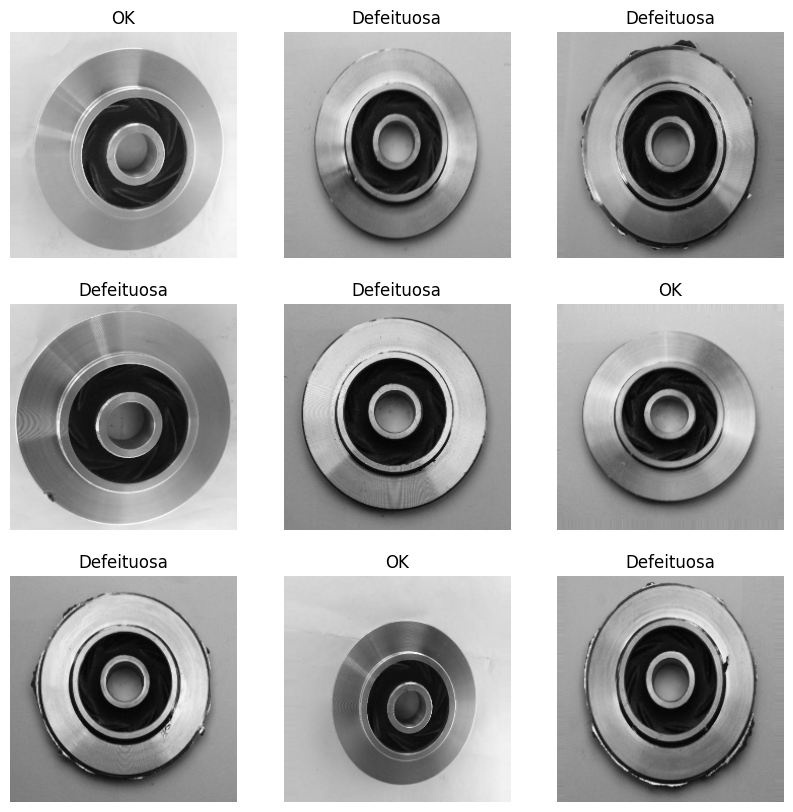

In [29]:
plt.figure(figsize=(10, 10))

for imagens, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(imagens[i].numpy().astype("uint8"))

        classe = "Defeituosa" if labels[i].numpy() == 0 else "OK"

        plt.title(classe)
        plt.axis("off")

plt.show()

In [30]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomBrightness(0.15)
], name="data_augmentation")

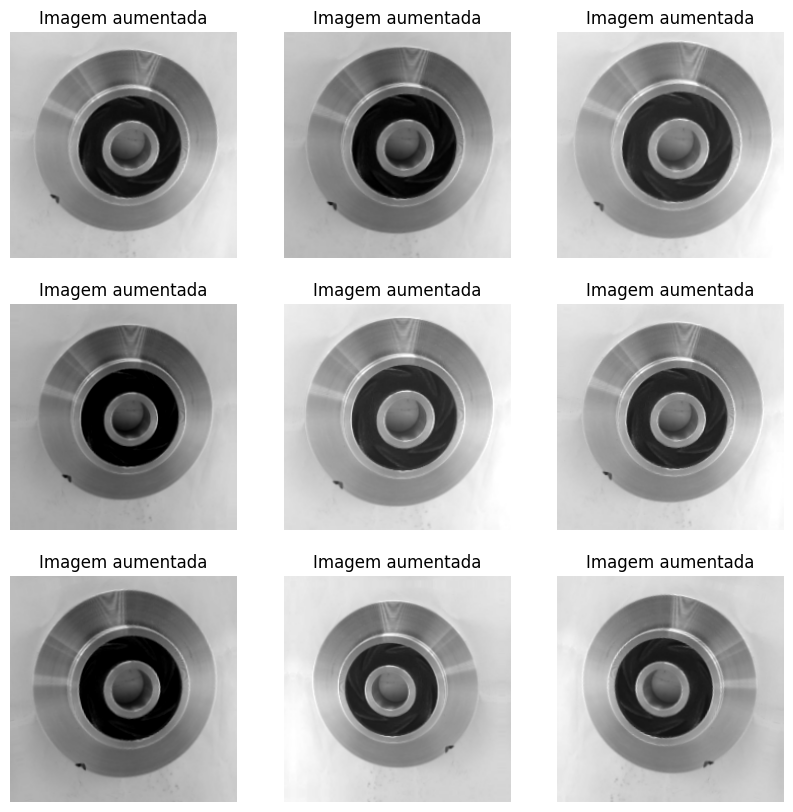

In [31]:
plt.figure(figsize=(10, 10))

for imagens, labels in train_ds.take(1):
    imagem = imagens[0]

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        imagem_aumentada = data_augmentation(
            tf.expand_dims(imagem, 0),
            training=True
        )

        plt.imshow(
            imagem_aumentada[0].numpy().astype("uint8")
        )

        plt.title("Imagem aumentada")
        plt.axis("off")

plt.show()

In [32]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Aumento artificial das imagens
    data_augmentation,

    # Normalização dos pixels
    tf.keras.layers.Rescaling(1./255),

    # Primeira camada convolucional
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Segunda camada convolucional
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Terceira camada convolucional
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Transformação para uma camada tradicional
    tf.keras.layers.Flatten(),

    # Camada totalmente conectada
    tf.keras.layers.Dense(128, activation="relu"),

    # Ajuda a reduzir overfitting
    tf.keras.layers.Dropout(0.3),

    # Saída binária: Defeituosa ou OK
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [33]:
modelo.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [34]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

history = modelo.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 314s 9s/step - accuracy: 0.6260 - loss: 0.6945 - val_accuracy: 0.7462 - val_loss: 0.5454
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.7048 - loss: 0.5730 - val_accuracy: 0.7808 - val_loss: 0.5039
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.7308 - loss: 0.5386 - val_accuracy: 0.7462 - val_loss: 0.4815
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.7692 - loss: 0.4827 - val_accuracy: 0.8346 - val_loss: 0.3648
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.7885 - loss: 0.4405 - val_accuracy: 0.8615 - val_loss: 0.3151
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.8048 - loss: 0.4013 - val_accuracy: 0.8308 - val_loss: 0.3386
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.8058 - loss: 0.4235 - val_accuracy: 0.8115 - val_loss: 0.3761
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.8173 - loss: 0.3758 - val_accuracy: 0.8231 - 

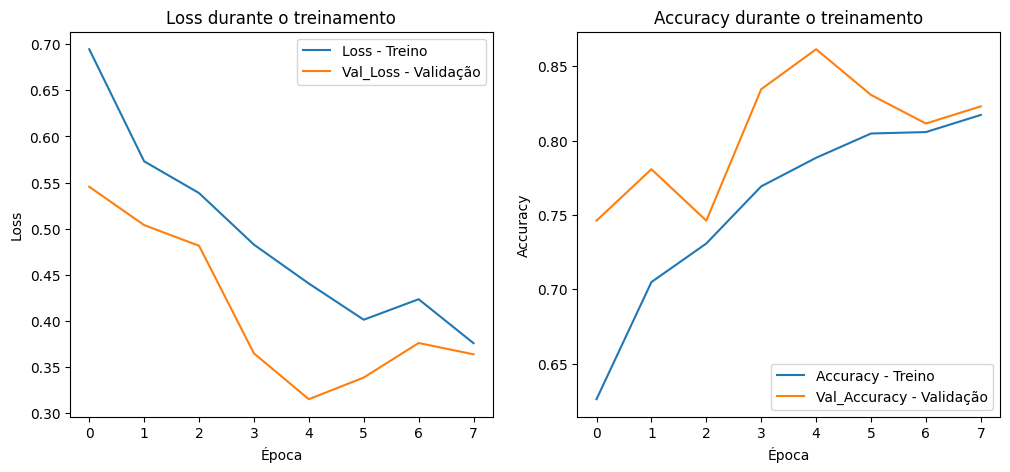

In [38]:
historico = history.history

plt.figure(figsize=(12, 5))

# Gráfico de Loss
plt.subplot(1, 2, 1)
plt.plot(historico["loss"], label="Loss - Treino")
plt.plot(historico["val_loss"], label="Val_Loss - Validação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss durante o treinamento")
plt.legend()

# Gráfico de Accuracy
plt.subplot(1, 2, 2)
plt.plot(historico["accuracy"], label="Accuracy - Treino")
plt.plot(historico["val_accuracy"], label="Val_Accuracy - Validação")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Accuracy durante o treinamento")
plt.legend()

plt.show()

In [39]:
resultado = modelo.evaluate(val_ds, verbose=1)

print(f"Loss na validação: {resultado[0]:.4f}")
print(f"Accuracy na validação: {resultado[1]:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.8615 - loss: 0.3151
Loss na validação: 0.3151
Accuracy na validação: 0.8615


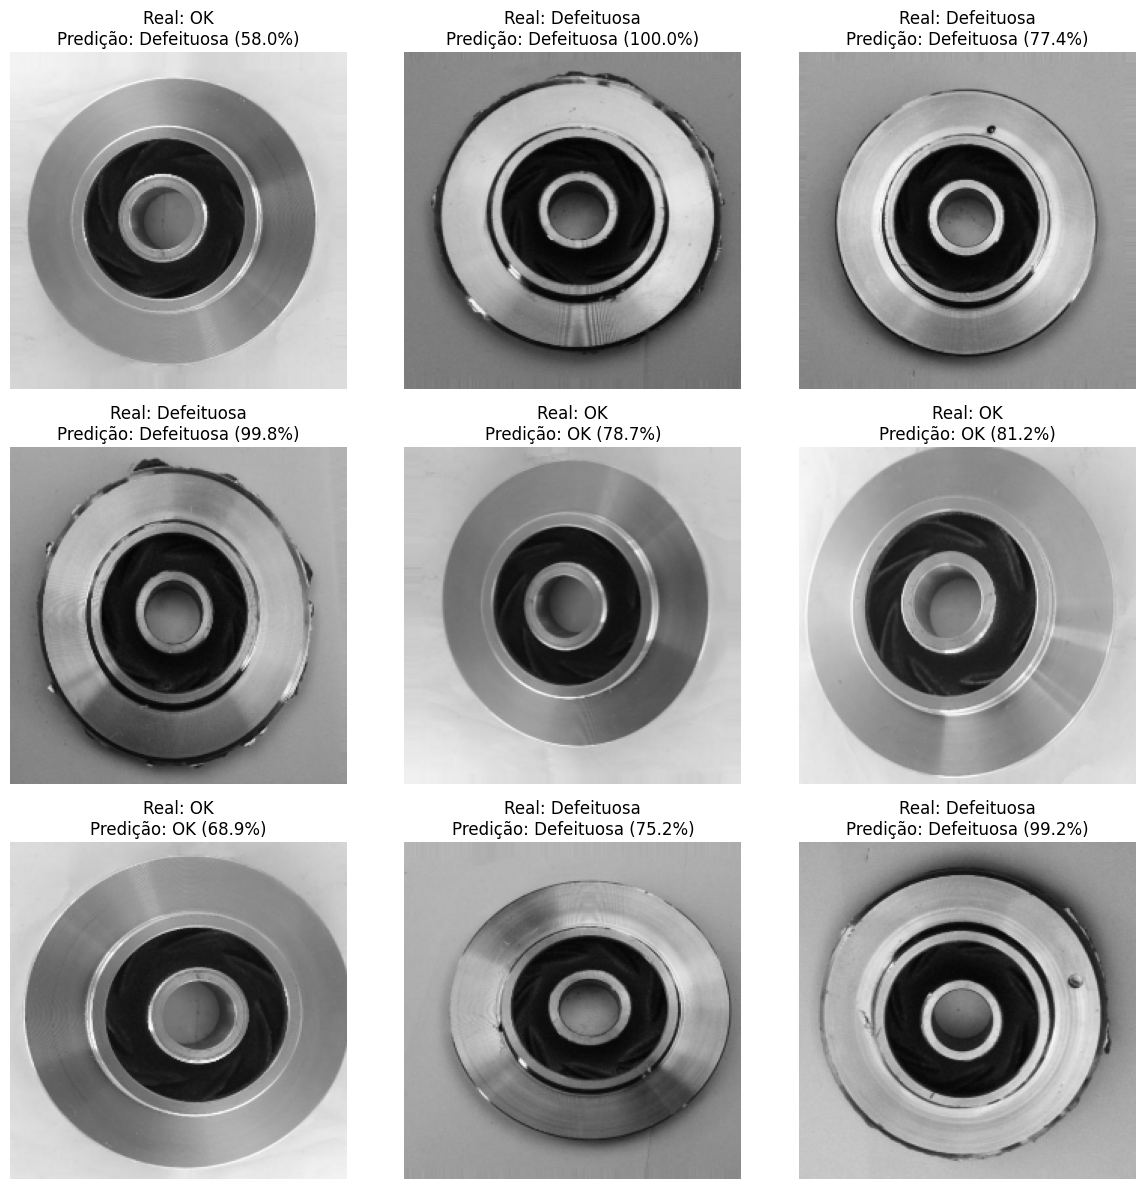

In [40]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

for imagens, labels in val_ds.take(1):
    previsoes = modelo.predict(imagens, verbose=0)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(imagens[i].numpy().astype("uint8"))

        real = "Defeituosa" if labels[i].numpy() == 0 else "OK"

        # Sigmoid: valores próximos de 0 = defeituosa
        # valores próximos de 1 = OK
        prevista = "OK" if previsoes[i][0] >= 0.5 else "Defeituosa"

        confianca = previsoes[i][0] if prevista == "OK" else 1 - previsoes[i][0]

        plt.title(
            f"Real: {real}\n"
            f"Predição: {prevista} ({confianca:.1%})"
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

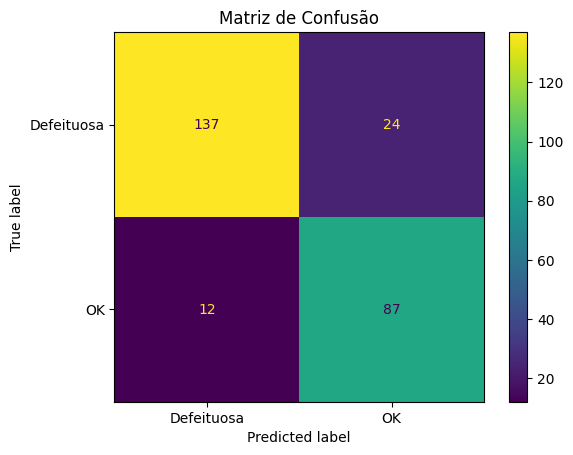

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for imagens, labels in val_ds:
    previsoes = modelo.predict(imagens, verbose=0)

    y_true.extend(labels.numpy().astype(int).flatten())
    y_pred.extend((previsoes.flatten() >= 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Defeituosa", "OK"]
)

disp.plot(values_format="d")
plt.title("Matriz de Confusão")
plt.show()

In [42]:
print("Relatório de classificação:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=["Defeituosa", "OK"]
))

Relatório de classificação:

              precision    recall  f1-score   support

  Defeituosa       0.92      0.85      0.88       161
          OK       0.78      0.88      0.83        99

    accuracy                           0.86       260
   macro avg       0.85      0.86      0.86       260
weighted avg       0.87      0.86      0.86       260



In [26]:
!git config --global user.name "Gustavo Mayer"
!git config --global user.email "gustavomiguelmayer@gmail.com"

In [27]:
%cd /content
!mkdir -p mini-projeto-visao-computacional
%cd /content/mini-projeto-visao-computacional
!git clone https://github.com/GustavoMMayer/mini-projeto-visao-computacional

/content
/content/mini-projeto-visao-computacional
Cloning into 'mini-projeto-visao-computacional'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 9 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 1000.48 KiB | 4.05 MiB/s, done.
Resolving deltas: 100% (1/1), done.
